<a href="https://colab.research.google.com/github/Datahuntl/Estudo-Comparativo-de-Detec-o-de-DeepFakes/blob/main/MesoNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# DEPENDÊNCIAS E CONFIGURAÇÃO DE HARDWARE

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score
import os
import shutil
import numpy as np
from PIL import Image
from google.colab import drive

# Conexão com o Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Para processar imagens massivas, precisamos obrigatoriamente da GPU (placa de vídeo).
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Rodando na instância: {device}")


Rodando na instância: cpu


In [ ]:
import shutil
import os

print("📦 Copiando o arquivo ZIP do Drive para o disco local do Colab...")
shutil.copy("/content/drive/MyDrive/IC DeepFakes/DATASET_FACES.zip", "/content/DATASET_FACES.zip")

print("🔓 Extraindo os arquivos no SSD local...")
!unzip -q /content/DATASET_FACES.zip -d /content/dataset_local/

print("✅ Concluído!")

In [ ]:
PATH_REAL = "/content/dataset_local/DATASET_FACES/REAL"
PATH_FAKE = "/content/dataset_local/DATASET_FACES/FAKE"

In [ ]:
class DeepfakeFaceDataset(Dataset):
    def __init__(self, real_face_dir, fake_face_dir, transform=None):
        self.real_images = [os.path.join(real_face_dir, img) for img in os.listdir(real_face_dir) if img.lower().endswith(('jpg', 'jpeg', 'png'))]
        self.fake_images = [os.path.join(fake_face_dir, img) for img in os.listdir(fake_face_dir) if img.lower().endswith(('jpg', 'jpeg', 'png'))]

        self.all_images = self.real_images + self.fake_images
        self.labels = [0] * len(self.real_images) + [1] * len(self.fake_images)
        self.transform = transform

    def __len__(self):
        return len(self.all_images)

    def __getitem__(self, idx):
        img_path = self.all_images[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)
        return image, label

transform_mesonet = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

full_dataset = DeepfakeFaceDataset(real_face_dir=PATH_REAL_FACES, fake_face_dir=PATH_FAKE_FACES, transform=transform_mesonet)

if len(full_dataset) == 0:
    print("\n❌ ERRO: Nenhuma foto localizada. Verifique os caminhos pós-unzip.")
else:
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size

    train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

    print(f"\n✅ Dataset MesoNet carregado com sucesso!")
    print(f"Total de imagens: {len(full_dataset)} | Treino: {train_size} | Validação: {val_size}")


✅ Dataset MesoNet carregado com sucesso!
Total de imagens encontradas: 48979 | Treino: 39183 | Validação: 9796


In [ ]:
class MesoInception4(nn.Module):
    def __init__(self, num_classes=1):
        super(MesoInception4, self).__init__()

        # Módulo Inception Simplificado
        self.conv1_1 = nn.Conv2d(3, 11, kernel_size=1, padding=0)
        self.conv1_2 = nn.Conv2d(3, 7, kernel_size=3, padding=1)
        self.conv1_3 = nn.Conv2d(3, 4, kernel_size=5, padding=2)
        self.conv1_4 = nn.Conv2d(3, 4, kernel_size=7, padding=3)

        self.bn1 = nn.BatchNorm2d(26)
        self.relu = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(26, 16, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm2d(16)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(16, 16, kernel_size=5, padding=2)
        self.bn3 = nn.BatchNorm2d(16)
        self.pool3 = nn.MaxPool2d(kernel_size=4, stride=4)

        self.conv4 = nn.Conv2d(16, 16, kernel_size=5, padding=2)
        self.bn4 = nn.BatchNorm2d(16)
        self.pool4 = nn.MaxPool2d(kernel_size=4, stride=4)

        self.fc = nn.Linear(16 * 4 * 4, 16)
        self.dropout = nn.Dropout(0.5)
        self.out = nn.Linear(16, num_classes)

    def forward(self, x):
        x1 = self.conv1_1(x)
        x2 = self.conv1_2(x)
        x3 = self.conv1_3(x)
        x4 = self.conv1_4(x)
        x = torch.cat((x1, x2, x3, x4), 1)
        x = self.pool1(self.relu(self.bn1(x)))

        x = self.pool2(self.relu(self.bn2(self.conv2(x))))
        x = self.pool3(self.relu(self.bn3(self.conv3(x))))
        x = self.pool4(self.relu(self.bn4(self.conv4(x))))

        x = x.view(x.size(0), -1)
        x = self.dropout(self.relu(self.fc(x)))
        x = torch.sigmoid(self.out(x))
        return x

model = MesoInception4().to(device)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score
from tqdm.auto import tqdm
import time

# --- CONFIGURAÇÃO DE DIRETÓRIOS PARA SALVAMENTO ---
CHECKPOINT_DIR = "/content/drive/MyDrive/IC DeepFakes/MesoNet_Outputs"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

checkpoint_path = os.path.join(CHECKPOINT_DIR, "mesonet_best_checkpoint.pth")
grafico_loss_path = os.path.join(CHECKPOINT_DIR, "curva_perda.png")
grafico_acc_path = os.path.join(CHECKPOINT_DIR, "curva_acuracia.png")

# --- CONFIGURAÇÃO DOS HIPERPARÂMETROS ---
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 5
start_epoch = 0
best_val_acc = 0.0

# Históricos para armazenar as métricas e plotar os gráficos depois
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

# --- 🔄 SEÇÃO DE RECUPERAÇÃO (RESUME CHECKPOINT) ---
if os.path.exists(checkpoint_path):
    print(f"🔄 Checkpoint encontrado em: {checkpoint_path}")
    print("Carregando estados do modelo e otimizador...")

    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_val_acc = checkpoint['best_val_acc']
    history = checkpoint['history']

    print(f"▶️ Resumindo o treinamento a partir da Época [{start_epoch+1}/{epochs}]")
    print(f"⭐ Melhor Acurácia de Validação registrada até agora: {best_val_acc:.4f}\n")
else:
    print("🆕 Nenhum checkpoint encontrado. Iniciando treinamento do zero.\n")

# --- 🏋️ LOOP DE TREINAMENTO MONITORADO ---
print("🚀 Iniciando o treinamento da MesoNet...\n")

for epoch in range(start_epoch, epochs):
    start_time = time.time()

    # --- FASE DE TREINO ---
    model.train()
    train_loss = 0.0
    all_train_labels = []
    all_train_preds = []

    # Criando a barra de progresso estilizada para os lotes de treino
    train_bar = tqdm(train_loader, desc=f"🎬 Época {epoch+1}/{epochs} [Treino]", leave=False)

    for batch_idx, (inputs, labels) in enumerate(train_bar):
        inputs, labels = inputs.to(device), labels.to(device).float().unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        current_loss = loss.item()
        train_loss += current_loss * inputs.size(0)

        # Predições parciais do lote
        preds_binary = (outputs.cpu().detach().numpy() > 0.5).astype(int)
        all_train_labels.extend(labels.cpu().numpy())
        all_train_preds.extend(preds_binary)

        # Atualiza as informações exibidas na barra de progresso a cada lote rodado
        if batch_idx % 2 == 0:
            batch_acc = accuracy_score(labels.cpu().numpy(), preds_binary)
            train_bar.set_postfix({
                "Loss Lote": f"{current_loss:.4f}",
                "Acc Lote": f"{batch_acc*100:.1f}%"
            })

    epoch_train_loss = train_loss / len(train_loader.dataset)
    epoch_train_acc = accuracy_score(all_train_labels, all_train_preds)

    # --- FASE DE VALIDAÇÃO ---
    model.eval()
    val_loss = 0.0
    all_labels = []
    all_preds = []

    val_bar = tqdm(val_loader, desc=f"🔍 Época {epoch+1}/{epochs} [Validação]", leave=False)

    with torch.no_grad():
        for inputs, labels in val_bar:
            inputs, labels_eval = inputs.to(device), labels.to(device).float().unsqueeze(1)
            outputs = model(inputs)

            loss = criterion(outputs, labels_eval)
            val_loss += loss.item() * inputs.size(0)

            all_labels.extend(labels.numpy())
            all_preds.extend(outputs.cpu().numpy())

    epoch_val_loss = val_loss / len(val_loader.dataset)

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    binary_preds = (all_preds > 0.5).astype(int)

    # Métricas Completas da Época
    epoch_val_acc = accuracy_score(all_labels, binary_preds)
    f1 = f1_score(all_labels, binary_preds, zero_division=0)
    prec = precision_score(all_labels, binary_preds, zero_division=0)
    rec = recall_score(all_labels, binary_preds, zero_division=0)
    try:
        auc = roc_auc_score(all_labels, all_preds)
    except:
        auc = 0.5

    # Guardar no histórico para os gráficos
    history["train_loss"].append(epoch_train_loss)
    history["val_loss"].append(epoch_val_loss)
    history["train_acc"].append(epoch_train_acc)
    history["val_acc"].append(epoch_val_acc)

    # --- OUTPUT CONSOLIDADO DA ÉPOCA ---
    epoch_time = time.time() - start_time
    print(f"📊 [FIM DA ÉPOCA {epoch+1}/{epochs}] Tempo: {epoch_time:.1f}s")
    print(f"   📈 Treino     -> Perda: {epoch_train_loss:.4f} | Acurácia: {epoch_train_acc*100:.2f}%")
    print(f"   📉 Validação  -> Perda: {epoch_val_loss:.4f} | Acurácia: {epoch_val_acc*100:.2f}%")
    print(f"   ✨ Métricas   -> AUC-ROC: {auc:.4f} | F1-Score: {f1:.4f} | Precisão: {prec:.4f} | Revocação: {rec:.4f}")

    # --- 💾 SALVAMENTO DE CHECKPOINT ---
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        print(f"   💾 ⭐ Nova melhor acurácia de validação! Salvando parâmetros no Drive...")
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_acc': best_val_acc,
            'history': history
        }, checkpoint_path)
    print("-" * 80)

print("🏆 Treinamento Concluído com Sucesso!")

🆕 Nenhum checkpoint encontrado. Iniciando treinamento do zero.

🚀 Iniciando o treinamento da MesoNet...



🎬 Época 1/5 [Treino]:   0%|          | 0/1225 [00:00<?, ?it/s]

🔍 Época 1/5 [Validação]:   0%|          | 0/307 [00:00<?, ?it/s]

📊 [FIM DA ÉPOCA 1/5] Tempo: 21634.0s
   📈 Treino     -> Perda: 0.3659 | Acurácia: 86.66%
   📉 Validação  -> Perda: 0.3184 | Acurácia: 86.27%
   ✨ Métricas   -> AUC-ROC: 0.8416 | F1-Score: 0.9263 | Precisão: 0.8627 | Revocação: 1.0000
   💾 ⭐ Nova melhor acurácia de validação! Salvando parâmetros no Drive...
--------------------------------------------------------------------------------


🎬 Época 2/5 [Treino]:   0%|          | 0/1225 [00:00<?, ?it/s]

🔍 Época 2/5 [Validação]:   0%|          | 0/307 [00:00<?, ?it/s]

📊 [FIM DA ÉPOCA 2/5] Tempo: 6821.3s
   📈 Treino     -> Perda: 0.2928 | Acurácia: 86.66%
   📉 Validação  -> Perda: 0.2698 | Acurácia: 86.27%
   ✨ Métricas   -> AUC-ROC: 0.9004 | F1-Score: 0.9263 | Precisão: 0.8627 | Revocação: 1.0000
--------------------------------------------------------------------------------


🎬 Época 3/5 [Treino]:   0%|          | 0/1225 [00:00<?, ?it/s]

KeyboardInterrupt: 


Gerando gráficos de desempenho de alta resolução...


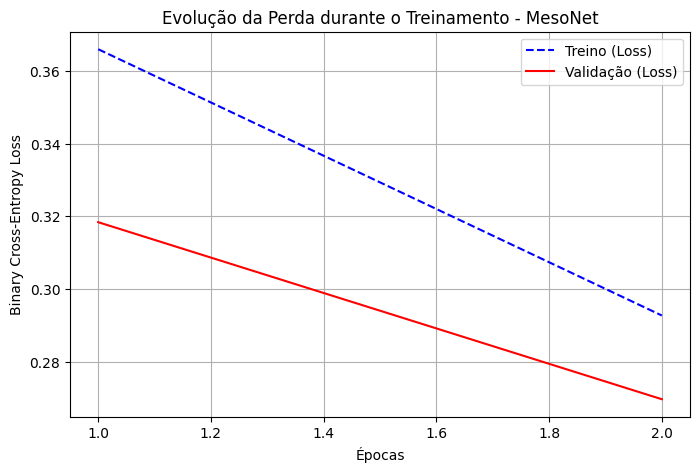

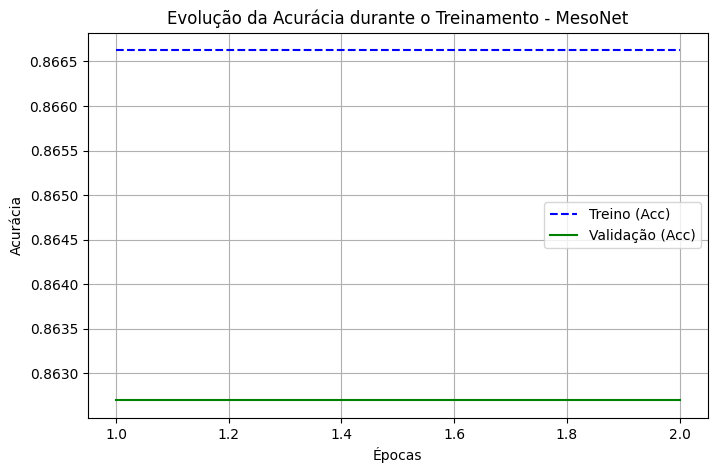

✨ Todos os artefatos visuais foram salvos na pasta: /content/drive/MyDrive/IC DeepFakes/MesoNet_Outputs


In [ ]:
print("\nGerando gráficos de desempenho de alta resolução...")

# 1. Gráfico de Perda
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(history["train_loss"])+1), history["train_loss"], label="Treino (Loss)", color="blue", linestyle="--")
plt.plot(range(1, len(history["val_loss"])+1), history["val_loss"], label="Validação (Loss)", color="red")
plt.title("Evolução da Perda durante o Treinamento - MesoNet")
plt.xlabel("Épocas")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.grid(True)
plt.savefig(grafico_loss_path, dpi=300, bbox_inches='tight')
plt.show()

# 2. Gráfico de Acurácia
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(history["train_acc"])+1), history["train_acc"], label="Treino (Acc)", color="blue", linestyle="--")
plt.plot(range(1, len(history["val_acc"])+1), history["val_acc"], label="Validação (Acc)", color="green")
plt.title("Evolução da Acurácia durante o Treinamento - MesoNet")
plt.xlabel("Épocas")
plt.ylabel("Acurácia")
plt.legend()
plt.grid(True)
plt.savefig(grafico_acc_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✨ Todos os artefatos visuais foram salvos na pasta: {CHECKPOINT_DIR}")